In [17]:

import sys
print (sys.executable)
#!{sys.executable} -m pip install xgboost
#!{sys.executable} -m pip install tensorflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping





/usr/bin/python3


In [18]:
file_path = "software_defect_dataset.csv"
data = pd.read_csv(file_path)
print("Dataset shape:", data.shape)
display(data.head())
target_column = "defects"
if data[target_column].dtype == "bool":
    data[target_column] = data[target_column].astype(int)
elif data[target_column].dtype == "object":
    data[target_column] = data[target_column].replace({
        "True": 1, "False": 0,
        "true": 1, "false": 0,
        "Yes": 1, "No": 0,
        "yes": 1, "no": 0
    })
    data[target_column] = data[target_column].astype(int)

print("\nDefect Distribution:")
print(data[target_column].value_counts())

Dataset shape: (10885, 22)


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1,1,1,1,1,True
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17,36,112,86,13,True
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17,135,329,271,5,True
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11,16,76,50,7,True



Defect Distribution:
defects
0    8779
1    2106
Name: count, dtype: int64


In [19]:

data.columns = data.columns.str.strip()

for col in data.select_dtypes(include="object").columns:
    data[col] = data[col].str.strip()

before = data.shape[0]
data = data.drop_duplicates().reset_index(drop=True)
print(f"Duplicate rows removed: {before - data.shape[0]}")
print("Dataset shape after cleaning:", data.shape)

X = data.drop(target_column, axis=1)
y = data[target_column]

X = X.replace("?", np.nan)
X = X.apply(pd.to_numeric, errors="coerce")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Duplicate rows removed: 1973
Dataset shape after cleaning: (8912, 22)
Training samples: (7129, 21)
Testing samples: (1783, 21)


In [20]:

results = []

def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)
    else:
        y_prob = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

    print(f"\n===== {model_name} =====")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{model_name} AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve")
    plt.legend()
    plt.show()


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.80      0.95      0.87      1381
           1       0.51      0.17      0.26       402

    accuracy                           0.78      1783
   macro avg       0.65      0.56      0.56      1783
weighted avg       0.73      0.78      0.73      1783



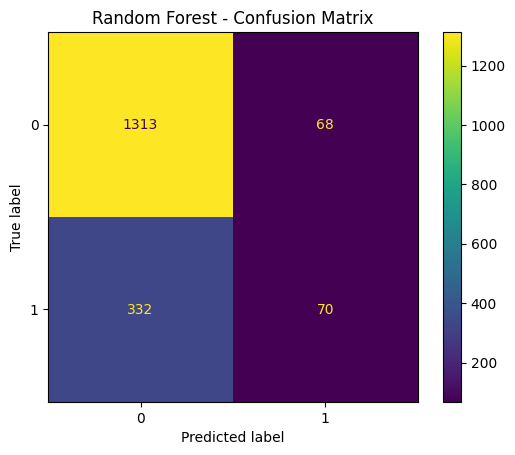

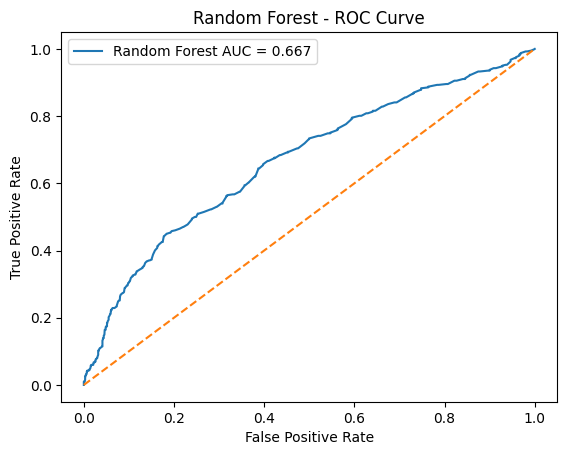


===== Support Vector Machine =====
              precision    recall  f1-score   support

           0       0.85      0.75      0.79      1381
           1       0.38      0.53      0.44       402

    accuracy                           0.70      1783
   macro avg       0.61      0.64      0.62      1783
weighted avg       0.74      0.70      0.71      1783



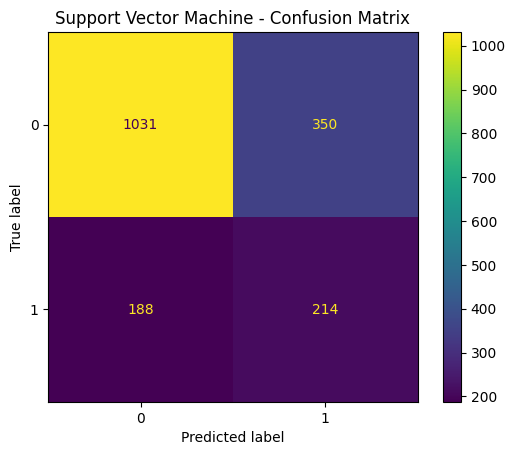

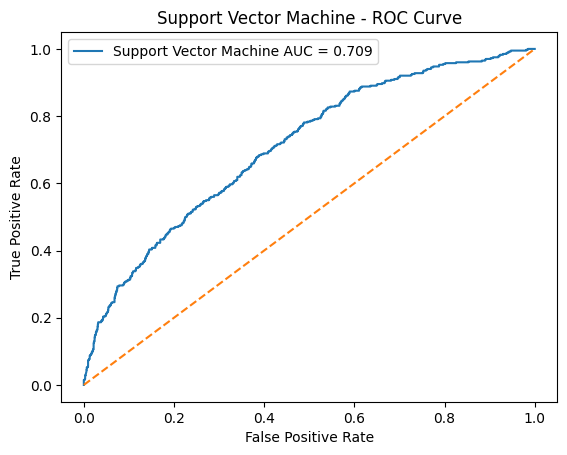


===== XGBoost =====
              precision    recall  f1-score   support

           0       0.80      0.97      0.88      1381
           1       0.59      0.16      0.26       402

    accuracy                           0.79      1783
   macro avg       0.70      0.57      0.57      1783
weighted avg       0.75      0.79      0.74      1783



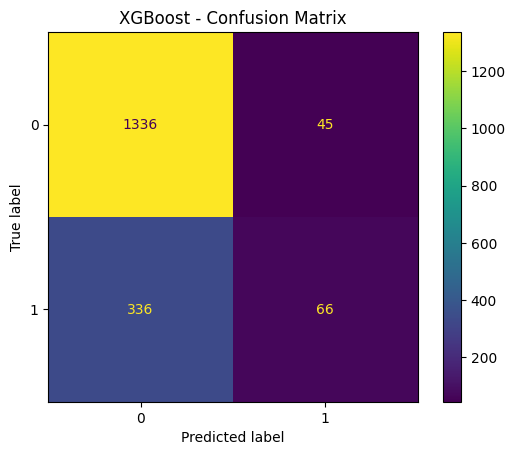

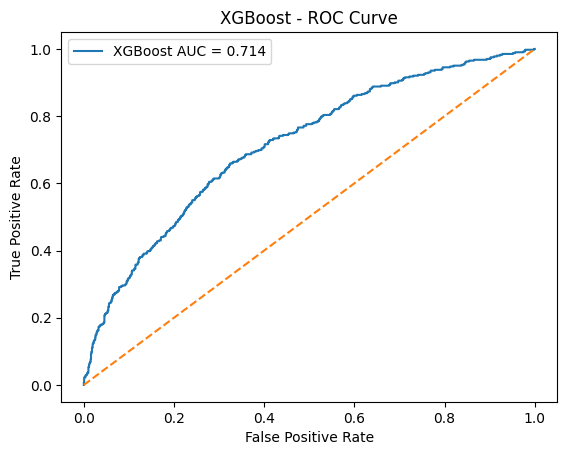


===== Gradient Boosting =====
              precision    recall  f1-score   support

           0       0.80      0.98      0.88      1381
           1       0.62      0.14      0.22       402

    accuracy                           0.79      1783
   macro avg       0.71      0.56      0.55      1783
weighted avg       0.76      0.79      0.73      1783



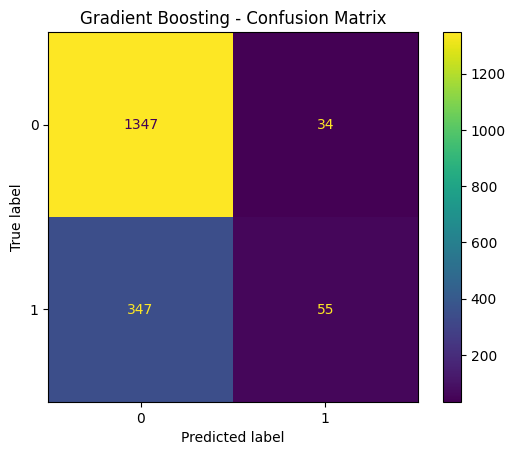

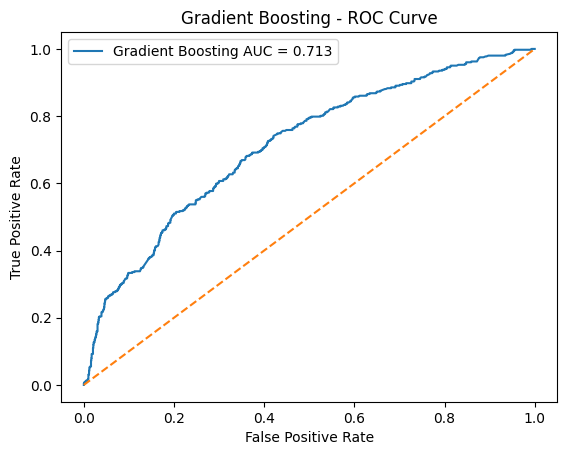

In [21]:

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)
evaluate_model("Random Forest", rf_model, X_test, y_test)



svm_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)
evaluate_model("Support Vector Machine", svm_model, X_test, y_test)

xgb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)
evaluate_model("XGBoost", xgb_model, X_test, y_test)

gb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)
evaluate_model("Gradient Boosting", gb_model, X_test, y_test)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


179/179 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7743 - loss: 0.5290 - val_accuracy: 0.7728 - val_loss: 0.5023
Epoch 2/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7768 - loss: 0.5039 - val_accuracy: 0.7756 - val_loss: 0.4987
Epoch 3/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7801 - loss: 0.4996 - val_accuracy: 0.7812 - val_loss: 0.4925
Epoch 4/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7813 - loss: 0.4959 - val_accuracy: 0.7798 - val_loss: 0.4915
Epoch 5/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7822 - loss: 0.4940 - val_accuracy: 0.7861 - val_loss: 0.4891
Epoch 6/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7826 - loss: 0.4913 - val_accuracy: 0.7826 - val_loss: 0.4912
Epoch 7/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7810 - loss: 0.4912 - val_accuracy: 0.7833 - val_loss: 0.4874
Epoch 8/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7815 - loss: 0.4911 - val_accuracy: 0.7840

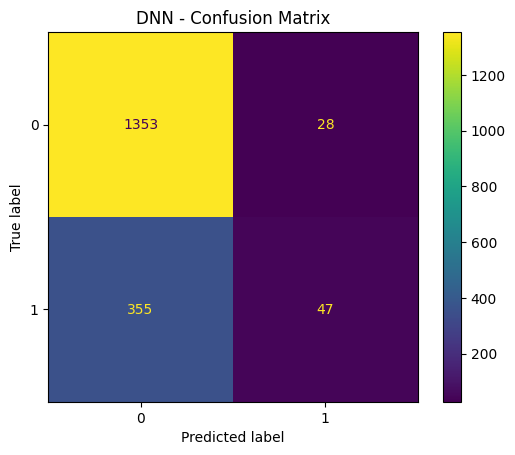

In [22]:


imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_dl = imputer.fit_transform(X_train)
X_test_dl = imputer.transform(X_test)

X_train_dl = scaler.fit_transform(X_train_dl)
X_test_dl = scaler.transform(X_test_dl)

dnn_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_dl.shape[1],)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

dnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = dnn_model.fit(
    X_train_dl,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

y_prob_dnn = dnn_model.predict(X_test_dl).ravel()
y_pred_dnn = (y_prob_dnn >= 0.5).astype(int)

results.append({
    "Model": "Deep Neural Network",
    "Accuracy": accuracy_score(y_test, y_pred_dnn),
    "Precision": precision_score(y_test, y_pred_dnn, zero_division=0),
    "Recall": recall_score(y_test, y_pred_dnn, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_dnn, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_dnn)
})

print("\n===== Deep Neural Network =====")
print(classification_report(y_test, y_pred_dnn, zero_division=0))

cm = confusion_matrix(y_test, y_pred_dnn)
ConfusionMatrixDisplay(cm).plot()
plt.title("DNN - Confusion Matrix")
plt.show()

In [23]:


X_train_cnn = X_train_dl.reshape(X_train_dl.shape[0], X_train_dl.shape[1], 1)
X_test_cnn = X_test_dl.reshape(X_test_dl.shape[0], X_test_dl.shape[1], 1)

cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation="relu", input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

y_prob_cnn = cnn_model.predict(X_test_cnn).ravel()
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)

results.append({
    "Model": "Convolutional Neural Network",
    "Accuracy": accuracy_score(y_test, y_pred_cnn),
    "Precision": precision_score(y_test, y_pred_cnn, zero_division=0),
    "Recall": recall_score(y_test, y_pred_cnn, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_cnn, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_cnn)
})

print("\n===== Convolutional Neural Network =====")
print(classification_report(y_test, y_pred_cnn, zero_division=0))

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7745 - loss: 0.5228 - val_accuracy: 0.7798 - val_loss: 0.4960
Epoch 2/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7785 - loss: 0.5050 - val_accuracy: 0.7784 - val_loss: 0.4951
Epoch 3/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7792 - loss: 0.4987 - val_accuracy: 0.7826 - val_loss: 0.4927
Epoch 4/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7794 - loss: 0.4966 - val_accuracy: 0.7798 - val_loss: 0.4994
Epoch 5/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7827 - loss: 0.4971 - val_accuracy: 0.7805 - val_loss: 0.4943
Epoch 6/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7856 - loss: 0.4956 - val_accuracy: 0.7791 - val_loss: 0.4921
Epoch 7/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7852 - loss: 0.4958 - val_accuracy: 0.7770 - val_loss: 0.4955
Epoch 8/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7843 - loss: 0.4973 - val_accuracy: 0.7798

In [24]:

X_cluster = imputer.fit_transform(X)
X_cluster = scaler.fit_transform(X_cluster)

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_cluster)

data["Cluster"] = clusters

print("\nK-Means Cluster Distribution:")
print(data["Cluster"].value_counts())

print("\nDefects by Cluster:")
display(pd.crosstab(data["Cluster"], data[target_column]))


K-Means Cluster Distribution:
Cluster
0    8668
1     244
Name: count, dtype: int64

Defects by Cluster:


defects,0,1
Cluster,,
0,6799,1869
1,106,138



===== Final Model Comparison =====


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Support Vector Machine,0.698261,0.379433,0.532338,0.443064,0.709113
0,Random Forest,0.775659,0.507246,0.174129,0.259259,0.667125
2,XGBoost,0.786315,0.594595,0.164179,0.257310,0.714334
3,Gradient Boosting,0.786315,0.617978,0.136816,0.224033,0.712730
4,Deep Neural Network,0.785193,0.626667,0.116915,0.197065,0.704258
5,Convolutional Neural Network,0.768929,0.343750,0.027363,0.050691,0.682004


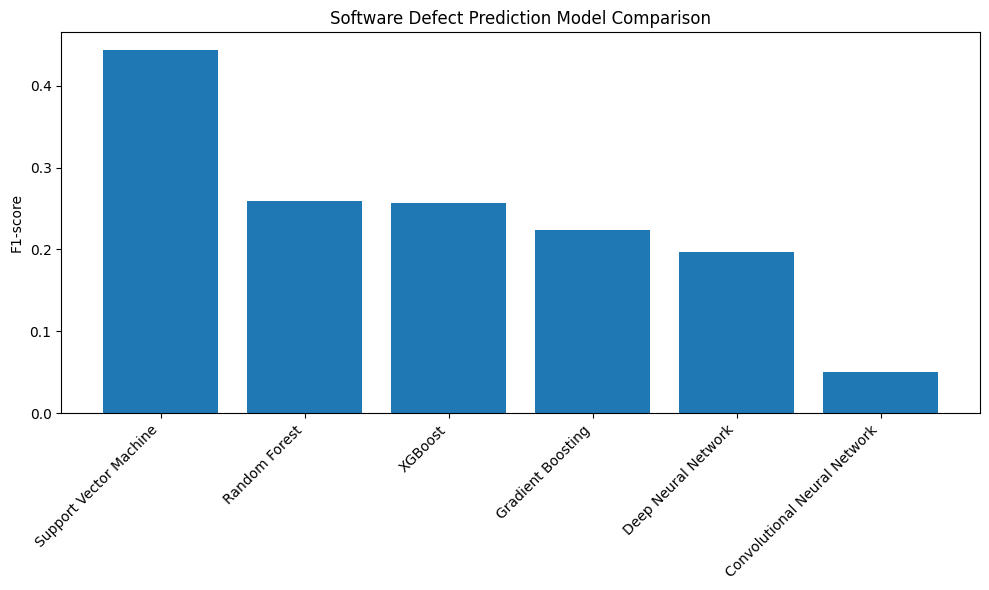

In [25]:


results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-score", ascending=False)

print("\n===== Final Model Comparison =====")
display(results_df)

results_df.to_csv("model_comparison_results.csv", index=False)

plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["F1-score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1-score")
plt.title("Software Defect Prediction Model Comparison")
plt.tight_layout()
plt.show()

In [26]:
import joblib

best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

joblib.dump(rf_model, "random_forest_defect_model.pkl")
joblib.dump(svm_model, "svm_defect_model.pkl")
joblib.dump(xgb_model, "xgboost_defect_model.pkl")

print("Models saved successfully.")

Best Model: Support Vector Machine
Models saved successfully.
